# InsightFlow Enterprise Analytics Platform

## Time Series Visualization Demo

This notebook demonstrates different time series visualization techniques using the Superstore dataset.

Topics Covered

- Loading Time Series Data
- Date Formatting
- Monthly Aggregation
- Trend Analysis
- Moving Average
- Seasonal Decomposition
- Handling Missing Dates

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [ ]:
## Load Dataset

In [19]:
df = pd.read_csv("../data/raw/Superstore.csv", encoding="latin1")

df["Order Date"] = pd.to_datetime(df["Order Date"])

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Create Monthly Sales Time Series

In [20]:
monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
      .sum()
)

## Basic Time Series Plot

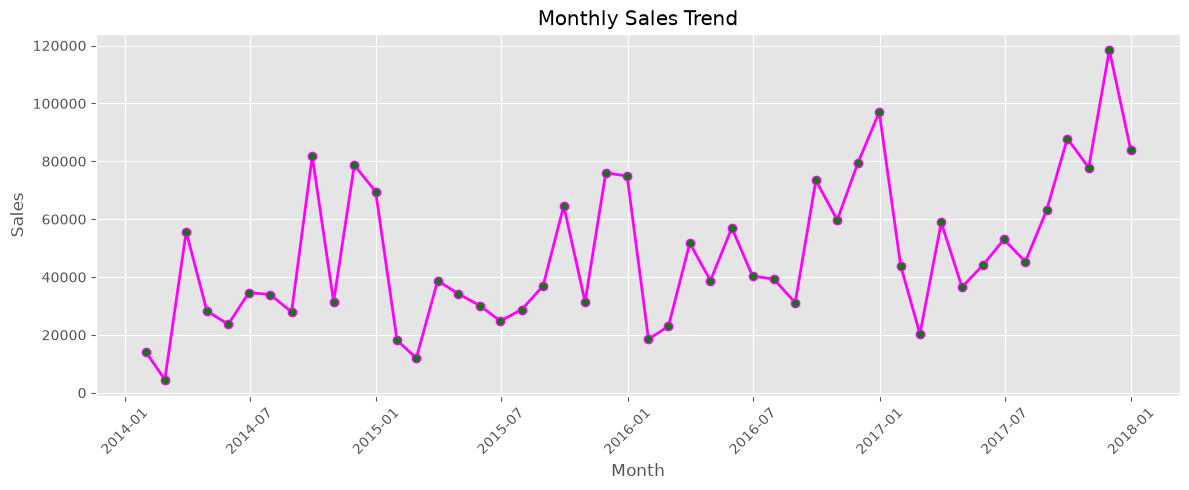

In [12]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o",
    linewidth=2,
    color='magenta',
    markerfacecolor= 'green'
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## Date Formatting

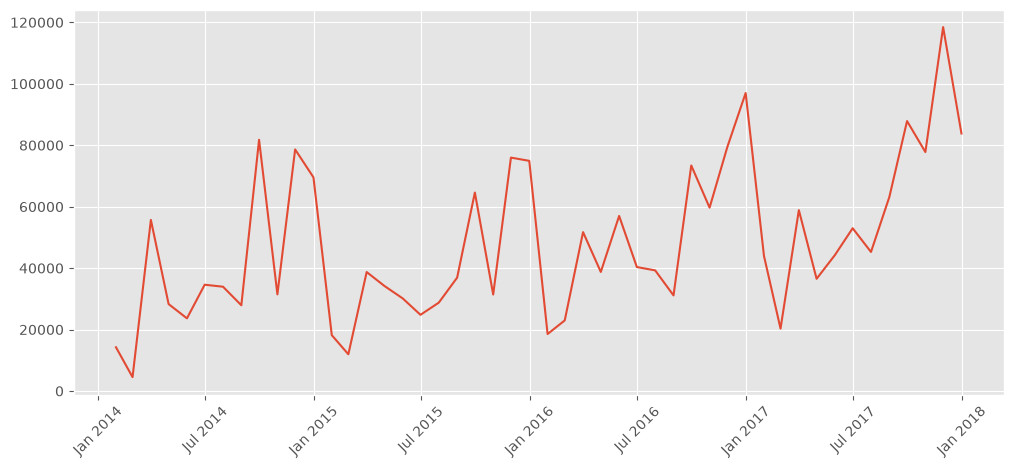

In [10]:
import matplotlib.dates as mdates

plt.figure(figsize=(12,5))

plt.plot(monthly_sales.index, monthly_sales)

ax = plt.gca()

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%b %Y")
)

plt.xticks(rotation=45)

plt.show()

## Moving Average Trend Line

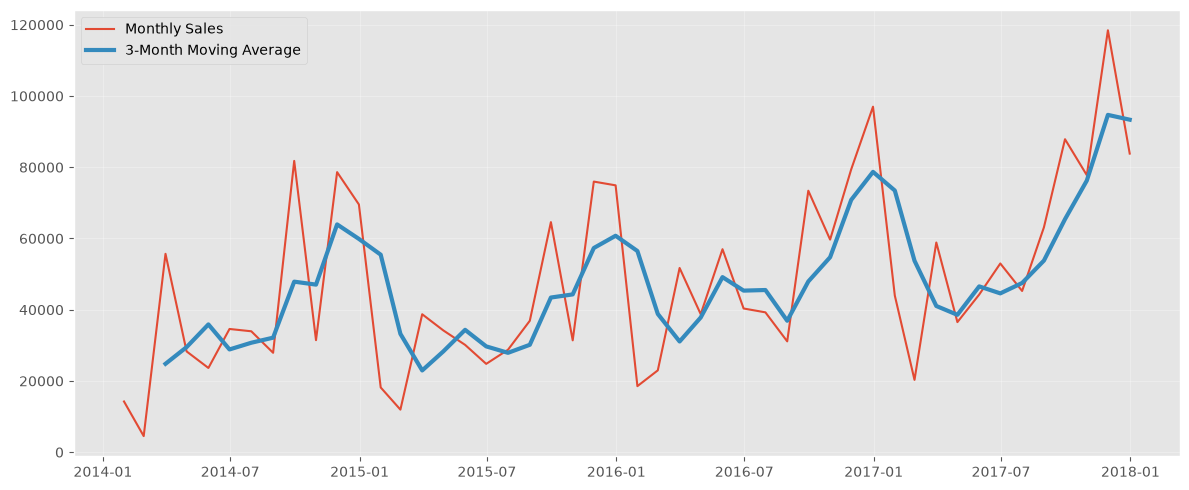

In [16]:
rolling_avg = monthly_sales.rolling(window=3).mean()

plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales,
    label="Monthly Sales"
)

plt.plot(
    rolling_avg,
    linewidth=3,
    label="3-Month Moving Average"
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("../assets/moving_average.png", dpi=300)

plt.show()

In [17]:
monthly_sales = monthly_sales.asfreq("ME")

monthly_sales = monthly_sales.fillna(0)

monthly_sales.head()

Order Date
2014-01-31    14236.895
2014-02-28     4519.892
2014-03-31    55691.009
2014-04-30    28295.345
2014-05-31    23648.287
Freq: ME, Name: Sales, dtype: float64

In [13]:
pip install statsmodels

     ---------------------------------------- 0.0/61.1 kB ? eta -:--:--
     ------ --------------------------------- 10.2/61.1 kB ? eta -:--:--
     ------------------- ------------------ 30.7/61.1 kB 660.6 kB/s eta 0:00:01
     -------------------------------------- 61.1/61.1 kB 820.5 kB/s eta 0:00:00
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.1/9.5 MB 6.1 MB/s eta 0:00:02
    --------------------------------------- 0.2/9.5 MB 2.6 MB/s eta 0:00:04
    --------------------------------------- 0.2/9.5 MB 2.0 MB/s eta 0:00:05
   - -------------------------------------- 0.3/9.5 MB 1.8 MB/s eta 0:00:06
   -- ------------------------------------- 0.5/9.5 MB 2.2 MB/s eta 0:00:05
   -- ------------------------------------- 0.6/9.5 MB 2.4 MB/s eta 0:00:04
   --- ------------------------------------ 0.8/9.5 MB 2.7 MB/s eta 0:00:04
   --- ------------------------------------ 0.9/9.5 MB 2.5 MB/s eta 0:00:04
   ---- ----------


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


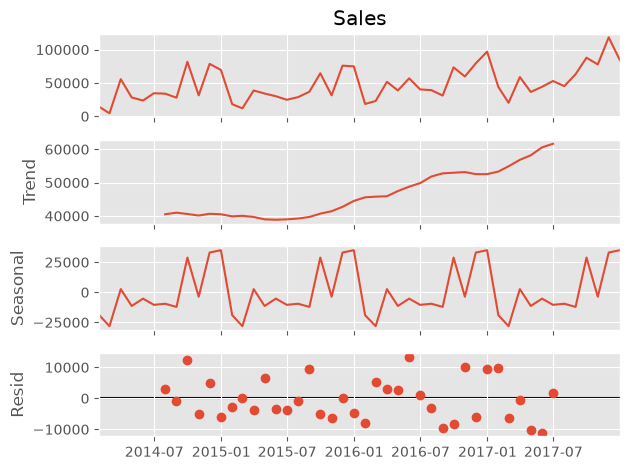

In [18]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(
    monthly_sales,
    model="additive",
    period=12
)

result.plot()

plt.show()

# Conclusion

This notebook demonstrated

- Time Series Plotting
- Date Formatting
- Trend Analysis
- Moving Average
- Seasonal Decomposition
- Missing Time Handling

These techniques are widely used in enterprise business analytics for understanding sales trends and forecasting.